In [4]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('Powerplant.csv')

In [6]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [ ]:
# AT => Temperature
# V => Vacuum
# AP => Pressure
# PE => Produced energy

In [7]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [8]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [9]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [12]:
X_train.shape

(7654, 4)

In [13]:
df.shape

(9568, 5)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [16]:
type(X_train_scaled)

numpy.ndarray

In [17]:
type(y_train)

pandas.core.series.Series

In [18]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [19]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Deep Learning

In [33]:
# Define our ANN Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            #1 hidden layer
            nn.Linear(4, 6),  # 4 input and 6 output in 1st hidden layer
            nn.ReLU(),

            # 2 hidden layer
            nn.Linear(6,6),  # 6 input from 1 layer and there will be  6 output in 2nd hidden layer
            nn.ReLU(),

            # Output Layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
       return self.model(x)

In [34]:
import torch.optim as optim

model  =ANN()

# Loss Function, Optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [35]:
# Train the ANN

train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 batch

    for xb, yb in train_loader:
        # xb => feature of 1 batch 
        # yb => label of 1 batch
        optimizer.zero_grad()

        outputs = model(xb)  # forward propagation ... predict output for this batch
# Basically ham yaha pe model ko input diye hai output predict karne ke liye same like we din in ML with predict func
        loss = crietrion(outputs, yb)  # Compute loss
        # Here it is comparing the output with real output
        loss.backward() # back propagation
        optimizer.step() # Params update 
        running_loss += loss.item() # loss in tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss =running_val_loss/ len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch ${epoch+1}/{epochs} ==> train loss = ${epoch_train_loss} & val loss = ${epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #use .pt or pth

epoch $1/100 ==> train loss = $205726.00279947917 & val loss = $202665.015625
epoch $2/100 ==> train loss = $190490.25501302083 & val loss = $172120.84375
epoch $3/100 ==> train loss = $145461.9357096354 & val loss = $117860.21875
epoch $4/100 ==> train loss = $95841.50486653646 & val loss = $77677.5390625
epoch $5/100 ==> train loss = $65083.518229166664 & val loss = $52497.23828125
epoch $6/100 ==> train loss = $42051.07172851563 & val loss = $30856.06640625
epoch $7/100 ==> train loss = $22648.926021321615 & val loss = $14584.2451171875
epoch $8/100 ==> train loss = $10458.164868164062 & val loss = $6878.75927734375
epoch $9/100 ==> train loss = $5862.9052744547525 & val loss = $4761.40673828125
epoch $10/100 ==> train loss = $4440.02115427653 & val loss = $3798.190185546875
epoch $11/100 ==> train loss = $3602.751168314616 & val loss = $3137.484375
epoch $12/100 ==> train loss = $3008.34958597819 & val loss = $2646.902587890625
epoch $13/100 ==> train loss = $2554.643022664388 & va

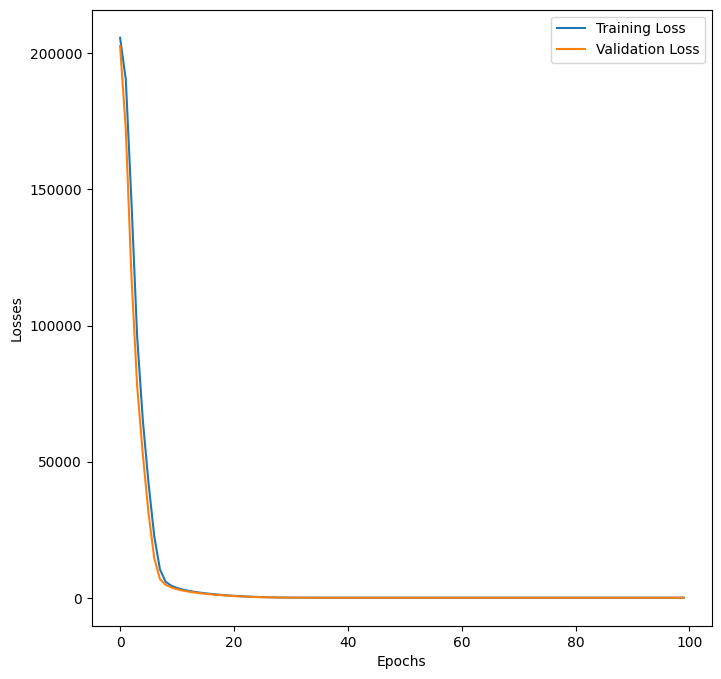

In [36]:
# Plot the graph 

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(8,8))
plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")



plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [37]:
print(best_val_loss)

tensor(18.6168)


In [38]:
# Loading the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [40]:
# Model evaluation

model.eval()
with torch.no_grad():
    train_pred =model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = crietrion(train_pred, y_train_tensor)
    test_mse_loss  = crietrion(test_pred, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE Loss :", test_mse_loss.item())

Training MSE: 20.399593353271484
Testing MSE Loss : 18.621322631835938


In [42]:
from sklearn.metrics import r2_score

print("R2 Score :" , r2_score(y_test, test_pred)*100)

R2 Score : 93.49232865791532


In [44]:
predicted_df = pd.DataFrame(test_pred.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,434.802765,433.27
1,436.779480,438.16
2,461.363037,458.42
3,476.471558,480.82
4,435.251129,441.41
...,...,...
1909,451.047974,456.70
1910,431.319946,438.04
1911,467.335999,467.80
1912,430.835938,437.14
